In [ ]:
#This line reaches into the astropy library (a massive toolkit for astronomers using Python) and pulls out a specific function called download_file. This tool is built specifically to handle downloading data from web links securely.
from astropy.utils.data import download_file
from astropy.io import fits
#Downloads the required file
image_file = download_file(

    'http://www.astropy.org/astropy-data/tutorials/FITS-images/HorseHead.fits',

    cache=True
)


In [ ]:
#Opens the image file and displays Header/Data units
hdu_list = fits.open(image_file)
hdu_list.info()

Filename: C:\Users\siddh\.astropy\cache\download\url\217b4fe80e6f349ef703ceed7e0be888\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


In [ ]:
#Displays information about the astronomical image
hdu_list[0].header

SIMPLE  =                    T /FITS: Compliance                                
BITPIX  =                   16 /FITS: I*2 Data                                  
NAXIS   =                    2 /FITS: 2-D Image Data                            
NAXIS1  =                  891 /FITS: X Dimension                               
NAXIS2  =                  893 /FITS: Y Dimension                               
EXTEND  =                    T /FITS: File can contain extensions               
DATE    = '2014-01-09        '  /FITS: Creation Date                            
ORIGIN  = 'STScI/MAST'         /GSSS: STScI Digitized Sky Survey                
SURVEY  = 'SERC-ER '           /GSSS: Sky Survey                                
REGION  = 'ER768   '           /GSSS: Region Name                               
PLATEID = 'A0JP    '           /GSSS: Plate ID                                  
SCANNUM = '01      '           /GSSS: Scan Number                               
DSCNDNUM= '00      '        

NAXIS1: The width of the image in pixels (the X-axis dimension).

NAXIS2: The height of the image in pixels (the Y-axis dimension).

DATE-OBS: The exact date and time when the telescope took this observation.

TELESCOP: The name of the telescope or observatory used to capture the image.

FILTER: The specific optical filter used (e.g., Red, Blue, or specific gas emission wavelengths) to isolate certain types of light.

EQUINOX: The coordinate system epoch (usually J2000). Because stars move slightly over time, coordinates must be tied to a specific year.

CRVAL1: The Right Ascension (celestial longitude) of the image's reference point.

CRVAL2: The Declination (celestial latitude) of the image's reference point.

DATAMIN: The lowest valid pixel value (minimum brightness) recorded in the data array.

DATAMAX: The highest valid pixel value (maximum brightness) recorded in the data array.

In [5]:
image_data = hdu_list[0].data

In [6]:
import numpy as np
print(image_data.shape)
print('Min:', np.min(image_data))
print('Max:', np.max(image_data))
print('Mean:', np.mean(image_data))
print('Std deviation:', np.std(image_data))


(893, 891)
Min: 3759
Max: 22918
Mean: 9831.481676287574
Std deviation: 3032.3927542049046


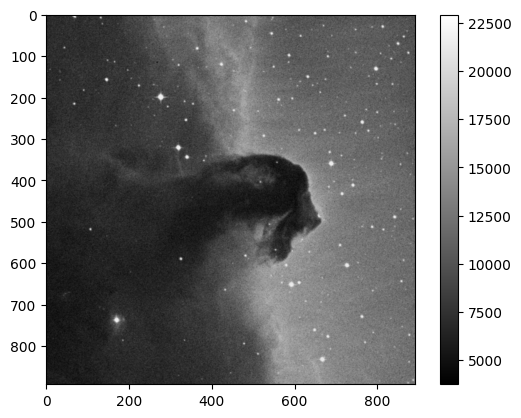

In [7]:
import matplotlib.pyplot as plt
plt.imshow(image_data, cmap='gray')  
plt.colorbar()

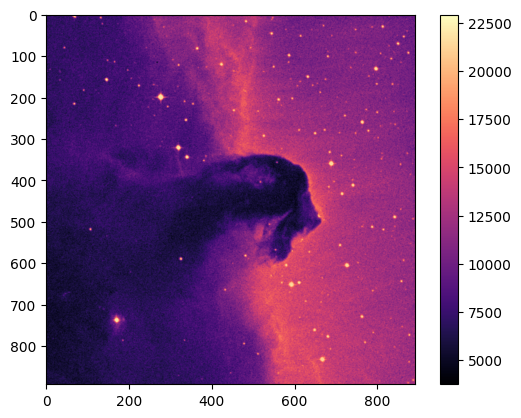

In [8]:
plt.imshow(image_data, cmap='magma')  
plt.colorbar()

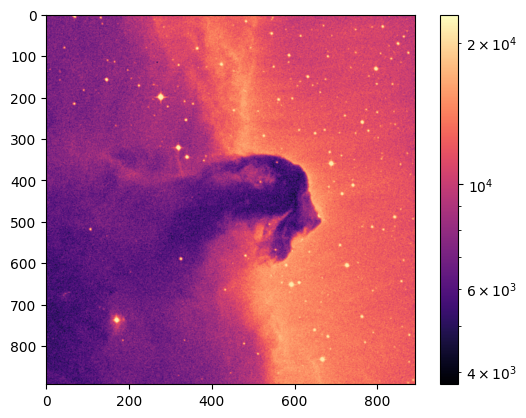

In [9]:
from matplotlib.colors import LogNorm
plt.imshow(image_data, cmap='magma', norm=LogNorm())

plt.colorbar()

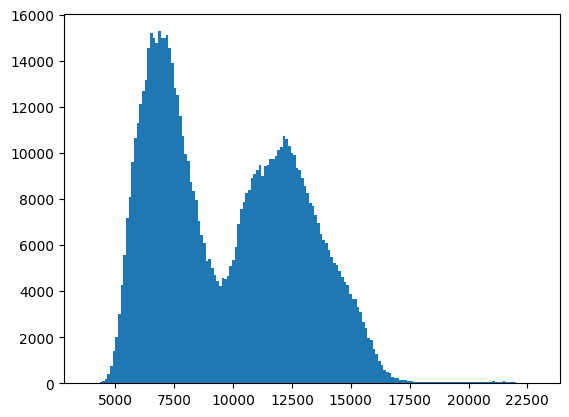

In [ ]:

image_data.flatten()
histogram = plt.hist(image_data.flatten(), bins='auto')

In standard linear scaling, the brightest stars dominate the image, causing fainter dust and gas structures to appear completely washed out or entirely black. Logarithmic scaling applies a mathematical log function to the pixel values, which heavily compresses the high (bright) values while expanding the low (dim) values. This brings out previously hidden, delicate details in the background, allowing us to see the extremely dim clouds forming the "horse head" shape simultaneously with the glaringly bright stars. Astronomers frequently use logarithmic visualization because astronomical objects have massive dynamic ranges; log scaling is often the only way to visually inspect a faint nebula and a bright star in a single image without losing data.